In [1]:
import os
import json
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [6]:
all_collected = []

for dirpath, _, files in os.walk(r"F:\FIP-data\images"):
    if "poses.json" in files:
        all_collected.append(dirpath)

In [14]:
focals = {}
radars = []

for c in all_collected:
    with open(os.path.join(c, "poses.json")) as f:
        d = json.load(f)
    if len(d) == 12:
        for k, v in d.items():
            focals.setdefault(k, [])
            focals[k].append(v["intrinsics"]["focal_length"])
        last = os.path.split(c)[1]
        with open(os.path.join(c, last.split("_")[0] + "_" + last.split("_")[1] + "_rig.json")) as f:
            w = json.load(f)
        radar = w["plant_distance"]
        if radar:
            radars.append(radar)
        else:
            radars.append(2500)

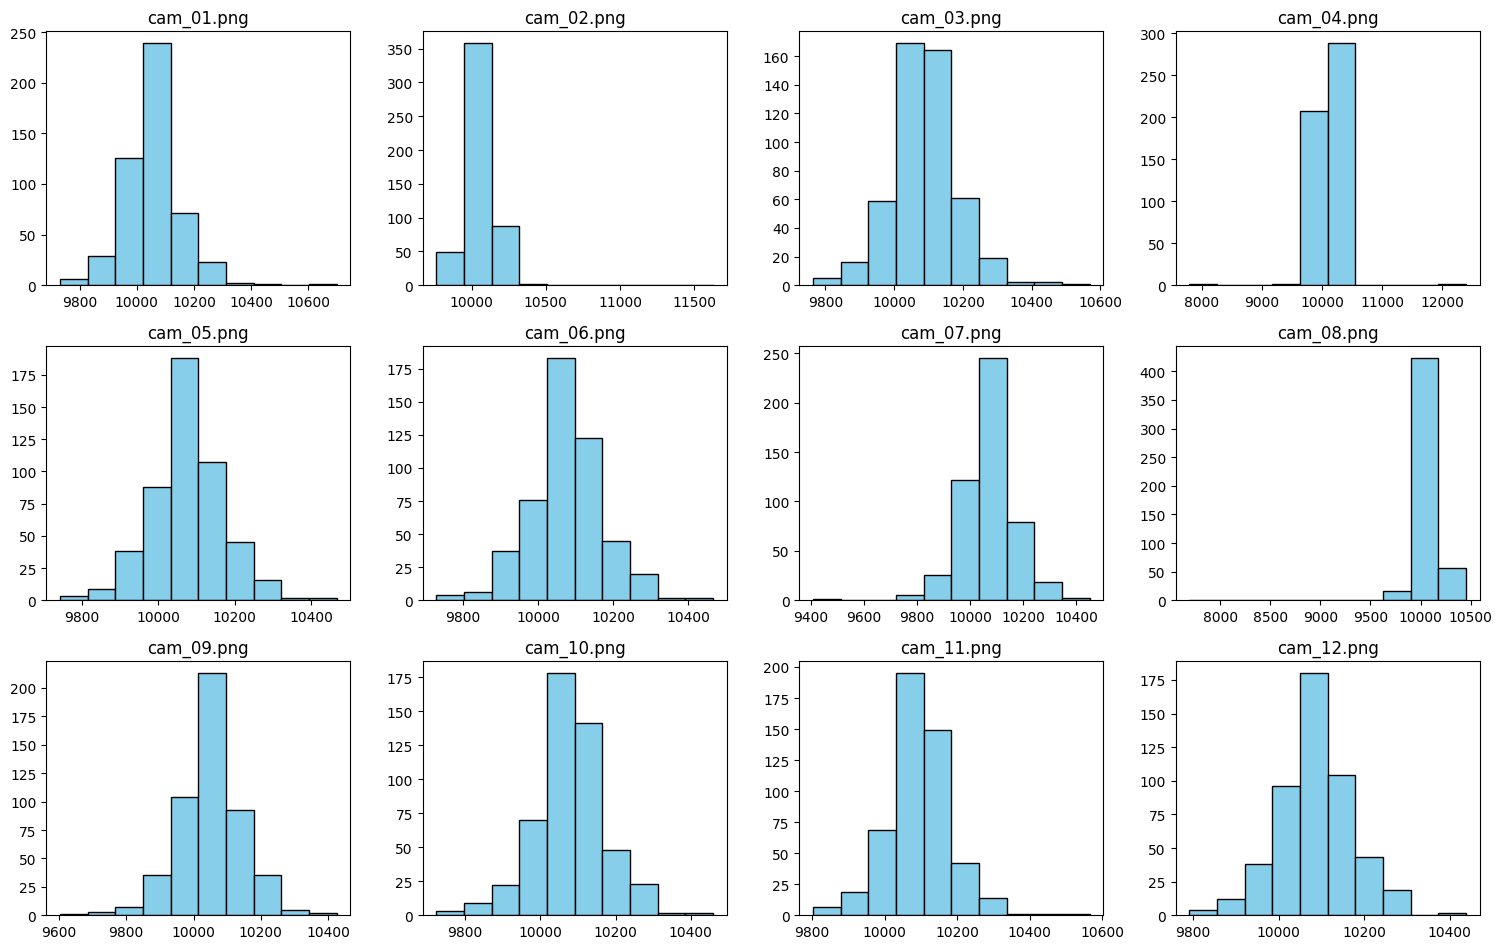

In [12]:
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
for idx, (key, values) in enumerate(focals.items()):
    row = idx // 4
    col = idx % 4
    axes[row, col].hist(values, bins=10, color='skyblue', edgecolor='black')
    axes[row, col].set_title(key)

# Adjust layout for better spacing
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [9]:
import numpy as np

u = {k: np.median(np.array(v)) for k, v in focals.items()}
print(u)

{'cam_01.png': 10057.608189231207, 'cam_02.png': 10064.599636267048, 'cam_03.png': 10085.26396537794, 'cam_04.png': 10111.166579231274, 'cam_05.png': 10077.86497657674, 'cam_06.png': 10076.407510342604, 'cam_07.png': 10071.23844743428, 'cam_08.png': 10073.892522940783, 'cam_09.png': 10053.707458887086, 'cam_10.png': 10080.605640198337, 'cam_11.png': 10094.705937320723, 'cam_12.png': 10085.675133414516}


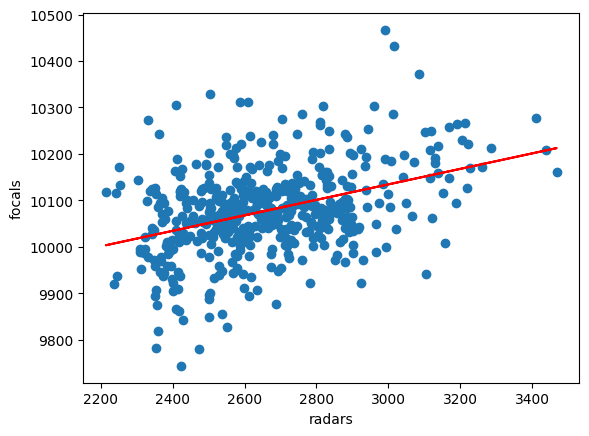

0.16670080246164018 * radar + 9634.159706800883


In [15]:
cam = "cam_03.png"

slope, intercept, r_value, p_value, std_err = linregress(radars, focals[cam])
def regression_line(x):
    return slope * x + intercept

plt.scatter(radars, focals[cam])
plt.plot(radars, [regression_line(xi) for xi in radars], color='red', label="Regression line")
plt.xlabel("radars")
plt.ylabel("focals")
plt.show()

print(f"{slope} * radar + {intercept}")

In [11]:
mapping = {}

for k, v in focals.items():
    slope, intercept, r_value, p_value, std_err = linregress(radars, focals[k])
    mapping[k] = (slope, intercept)

print(mapping)

{'cam_01.png': (0.17673331477901844, 9530.035254373397), 'cam_02.png': (0.17331549264743165, 9548.864223309742), 'cam_03.png': (0.19916796390992236, 9494.175132345183), 'cam_04.png': (0.17149694106928104, 9596.678688906339), 'cam_05.png': (0.24924534577586174, 9353.458675560674), 'cam_06.png': (0.22014159591312138, 9435.167727120324), 'cam_07.png': (0.251777615636003, 9347.220352681334), 'cam_08.png': (0.27099496141011836, 9292.946995161974), 'cam_09.png': (0.27684184329891653, 9263.55753990981), 'cam_10.png': (0.26332516569589537, 9324.141285825848), 'cam_11.png': (0.17323378607016485, 9582.929318933833), 'cam_12.png': (0.22748550981767562, 9427.521382588078)}
